# Experiment: optimising for Sortino instead of Sharpe

`src/portfolio/optimise.py` maximises the **Sharpe ratio** (mean-variance / Markowitz) because portfolio variance is a clean quadratic function of the weights, which makes it a convex optimisation problem with a reliable, unique solution. The **Sortino ratio** uses downside deviation instead of total deviation, which depends on which returns end up below a target — and that set depends on the very weights being solved for. No closed-form solution in general.

This notebook is a scratch experiment to see what optimising for Sortino actually looks like in practice, using PyPortfolioOpt's `EfficientSemivariance` (Estrada's semi-covariance approximation). **This implementation lives only here for now** — nothing in `src/` or `app.py` changes as part of this.

Kernel: select **portfolio-constructor** (the project's `.venv`).

In [1]:
%load_ext autoreload
%autoreload 2

import sys
from pathlib import Path

project_root = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(project_root))

import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pypfopt import expected_returns, EfficientSemivariance

from src import config
from src.data import ingest, features
from src.models import ranker
from src.portfolio import backtest, optimise
from src.risk import metrics

# EfficientSemivariance throws the occasional numpy RuntimeWarning at the
# extreme ends of the target-return grid searched below (near-degenerate
# portfolios where semi-deviation is ~0) — harmless, just noisy.
warnings.filterwarnings("ignore")

## 1. Pull data (cached after the first run)

In [2]:
prices_long = ingest.load_or_fetch_prices(
    config.TICKER_UNIVERSE + [config.BENCHMARK_TICKER], config.DATA_START_DATE, config.DATA_END_DATE
)
dividends = ingest.load_or_fetch_dividends(config.TICKER_UNIVERSE, config.DATA_START_DATE, config.DATA_END_DATE)
prices = ingest.to_wide_adj_close(prices_long)
universe_prices = prices[config.TICKER_UNIVERSE]
print("prices (wide):", prices.shape)

prices (wide): (3922, 40)


## 2. Why there's no one-shot "maximise Sortino" call

`EfficientFrontier.max_sharpe()` exists because the Sharpe-maximising (tangency) portfolio has a direct solution. `EfficientSemivariance` in this version of PyPortfolioOpt actually raises `NotImplementedError` if you try `.max_sharpe()` on it — there's no equivalent direct solver for the Sortino-maximising portfolio, which is itself a small, concrete illustration of the point above.

The workaround: scan the semi-variance efficient frontier by asking for the minimum-semivariance portfolio at a range of target returns (`efficient_return(target_return)`), compute the realised Sortino ratio at each point, and keep the best one. It's an approximate search, not an exact solve — more points means a closer approximation at the cost of more computation.

In [3]:
def max_sortino_weights(training_prices: pd.DataFrame, risk_free_rate: float = config.RISK_FREE_RATE_ANNUAL, n_points: int = 15) -> dict:
    """Approximate the Sortino-ratio-maximising portfolio by scanning the
    semi-variance efficient frontier and keeping the best point.

    Mirrors optimise.max_sharpe_weights's bounds (MAX_WEIGHT_PER_STOCK, long-only)
    so the two are a fair comparison — same universe, same constraints, different objective.
    """
    mu = expected_returns.mean_historical_return(training_prices, frequency=config.TRADING_DAYS_PER_YEAR)
    historical_returns = expected_returns.returns_from_prices(training_prices)

    # Skip the exact min/max of mu: those targets are typically only
    # achievable by a near-single-stock portfolio, which is a degenerate
    # edge case for a downside-deviation-based objective.
    candidate_returns = np.linspace(mu.min(), mu.max(), n_points + 2)[1:-1]

    best_sortino, best_weights = -np.inf, None
    for target_return in candidate_returns:
        try:
            frontier = EfficientSemivariance(
                mu, historical_returns, frequency=config.TRADING_DAYS_PER_YEAR,
                weight_bounds=(0, config.MAX_WEIGHT_PER_STOCK),
            )
            frontier.efficient_return(target_return)
            portfolio_return, semi_deviation, _ = frontier.portfolio_performance(risk_free_rate=risk_free_rate)
            sortino = (portfolio_return - risk_free_rate) / semi_deviation
            if np.isfinite(sortino) and sortino > best_sortino:
                best_sortino, best_weights = sortino, frontier.clean_weights()
        except Exception:
            continue  # that target return wasn't reachable under the weight bounds

    return best_weights

## 3. Sanity check: compare weights at a single point in time

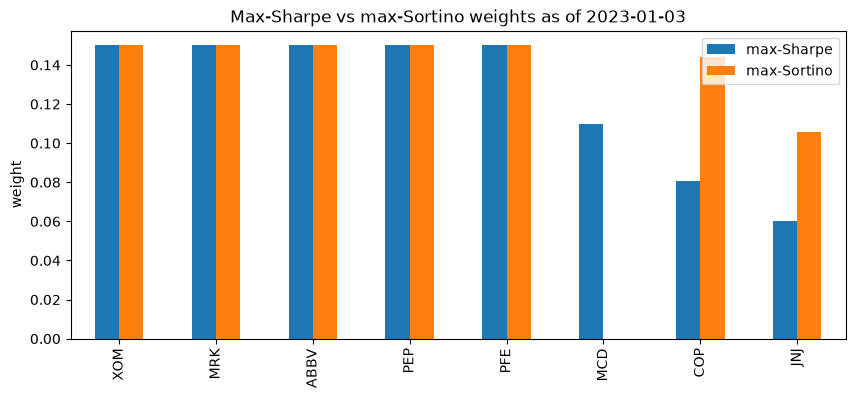

,max-Sharpe,max-Sortino
XOM,0.15000,0.15000
MRK,0.15000,0.15000
ABBV,0.15000,0.15000
PEP,0.15000,0.15000
PFE,0.15000,0.15000
MCD,0.10959,0.00000
COP,0.08039,0.14415
JNJ,0.06002,0.10590


In [4]:
as_of_date = pd.Timestamp("2023-01-03")

momentum = features.compute_momentum(universe_prices, as_of_date)
low_volatility = features.compute_low_volatility(universe_prices, as_of_date)
dividend_yield = features.compute_dividend_yield(dividends, universe_prices, as_of_date)
scores = ranker.score_stocks(momentum, low_volatility, dividend_yield)
top_holdings = ranker.select_top_n(scores, n=config.TOP_N_HOLDINGS)

training_window = features.training_window(universe_prices, as_of_date)[list(top_holdings)]

sharpe_weights = pd.Series(optimise.max_sharpe_weights(training_window)).rename("max-Sharpe")
sortino_weights = pd.Series(max_sortino_weights(training_window)).rename("max-Sortino")

comparison_weights = pd.concat([sharpe_weights, sortino_weights], axis=1)
comparison_weights = comparison_weights[(comparison_weights > 0).any(axis=1)].sort_values("max-Sharpe", ascending=False)

comparison_weights.plot.bar(figsize=(10, 4), title=f"Max-Sharpe vs max-Sortino weights as of {as_of_date.date()}")
plt.ylabel("weight")
plt.show()
comparison_weights

## 4. Full walk-forward comparison

This reuses `backtest`'s rebalancing/turnover/cost machinery directly — including a couple of its "private" (underscore-prefixed) helper functions — rather than re-implementing the walk-forward loop from scratch. That's a deliberate shortcut for this scratch experiment, not something production code in `src/` should do.

**This takes roughly 1–2 minutes** — the frontier scan means ~15x more optimiser calls per rebalance than the single-shot max-Sharpe strategy.

In [5]:
# Baseline: the existing max-Sharpe composite strategy, for a like-for-like comparison.
sharpe_daily_returns, _ = backtest.run_backtest(prices, dividends)

In [6]:
def get_target_weights_sortino(rebalance_date: pd.Timestamp) -> dict:
    training_window = features.training_window(universe_prices, rebalance_date)
    momentum = features.compute_momentum(training_window, rebalance_date)
    low_volatility = features.compute_low_volatility(training_window, rebalance_date)
    dividend_yield = features.compute_dividend_yield(dividends, training_window, rebalance_date)
    scores = ranker.score_stocks(momentum, low_volatility, dividend_yield)
    top_holdings = ranker.select_top_n(scores, n=config.TOP_N_HOLDINGS)
    return max_sortino_weights(training_window[list(top_holdings)])


start, end = pd.Timestamp(config.BACKTEST_START_DATE), pd.Timestamp(config.BACKTEST_END_DATE)
rebalance_dates = backtest.get_rebalance_dates(universe_prices, start, end)
sortino_gross, sortino_net, sortino_log = backtest._run_rebalanced_series(
    universe_prices, rebalance_dates, end, get_target_weights_sortino
)
print("done —", len(sortino_log), "rebalances")

done — 139 rebalances


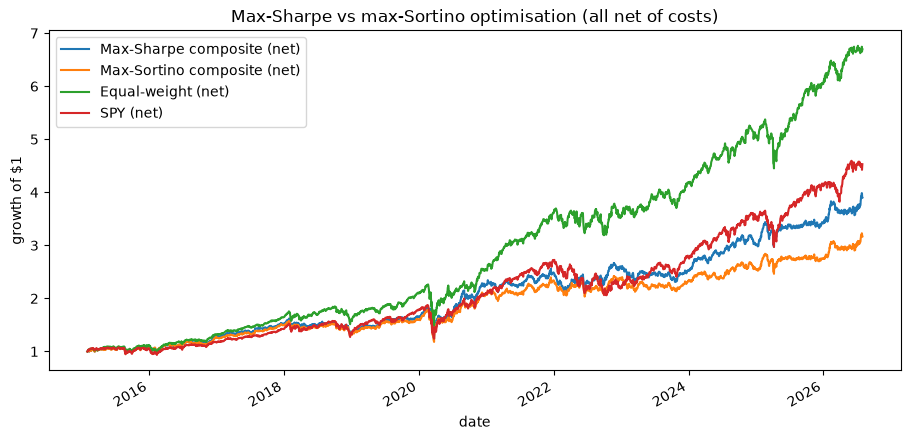

In [7]:
four_way = pd.DataFrame(
    {
        "Max-Sharpe composite (net)": sharpe_daily_returns["strategy_net"],
        "Max-Sortino composite (net)": sortino_net,
        "Equal-weight (net)": sharpe_daily_returns["equal_weight_net"],
        "SPY (net)": sharpe_daily_returns["sp500_net"],
    }
)
(1 + four_way).cumprod().plot(figsize=(11, 5), title="Max-Sharpe vs max-Sortino optimisation (all net of costs)")
plt.ylabel("growth of $1")
plt.show()

In [8]:
optimiser_comparison = pd.DataFrame(
    {
        "max_sharpe": metrics.compute_all(sharpe_daily_returns["strategy_net"]),
        "max_sortino": metrics.compute_all(sortino_net),
        "equal_weight": metrics.compute_all(sharpe_daily_returns["equal_weight_net"]),
        "SPY": metrics.compute_all(sharpe_daily_returns["sp500_net"]),
    }
)
optimiser_comparison

,max_sharpe,max_sortino,equal_weight,SPY
sharpe_ratio,0.684786,0.583231,0.972167,0.722204
sortino_ratio,0.852429,0.725731,1.152840,0.883576
max_drawdown,-0.327383,-0.339079,-0.342338,-0.337172
historical_var_95,-0.014101,-0.013237,-0.014389,-0.016560
monte_carlo_var_95,-0.016723,-0.016410,-0.016562,-0.017993
expected_shortfall_95,-0.023456,-0.022959,-0.024643,-0.026818
var_breaches_95,145.000000,145.000000,145.000000,145.000000
historical_var_99,-0.027314,-0.026522,-0.028167,-0.031695
monte_carlo_var_99,-0.023931,-0.023456,-0.023782,-0.025758
expected_shortfall_99,-0.043881,-0.043317,-0.045058,-0.046305
